# StayPredict — 03. Model Training & Comparison
Benchmarking multiple regression algorithms for hospital length-of-stay prediction.


In [14]:
import joblib
import time
import numpy as np
import pandas as pd
from pathlib import Path
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Load preprocessed arrays and feature names
data = joblib.load("../data/processed/split_data.joblib")

X_train_processed = data['X_train_processed']
X_test_processed = data['X_test_processed']
y_train = data['y_train']
y_test = data['y_test']
feature_names = data['feature_names']

print("--- PREPROCESSED DATA LOADED ---")
print(f"X_train_processed shape: {X_train_processed.shape}")
print(f"X_test_processed shape:  {X_test_processed.shape}")
print(f"y_train shape:           {y_train.shape}")
print(f"y_test shape:            {y_test.shape}")
print(f"Features:                {len(feature_names)} features")


--- PREPROCESSED DATA LOADED ---
X_train_processed shape: (43972, 29)
X_test_processed shape:  (10994, 29)
y_train shape:           (43972,)
y_test shape:            (10994,)
Features:                29 features


In [15]:
# Reusable evaluation helper
def evaluate_model(model_name, model, X_train, y_train, X_test, y_test):
    # Track training time
    start_time = time.time()
    model.fit(X_train, y_train)
    fit_time = time.time() - start_time
    
    # Generate predictions
    train_preds = model.predict(X_train)
    test_preds = model.predict(X_test)
    
    # Compute metrics on Test set
    mae = mean_absolute_error(y_test, test_preds)
    mse = mean_squared_error(y_test, test_preds)
    rmse = np.sqrt(mse)
    r2 = r2_score(y_test, test_preds)
    
    # Also compute train metrics to detect overfitting
    train_mae = mean_absolute_error(y_train, train_preds)
    train_r2 = r2_score(y_train, train_preds)
    
    return {
        'Model': model_name,
        'Test MAE (days)': round(mae, 4),
        'Test RMSE (days)': round(rmse, 4),
        'Test R²': round(r2, 4),
        'Train MAE (days)': round(train_mae, 4),
        'Train R²': round(train_r2, 4),
        'Train Time (s)': round(fit_time, 4),
        'Model_Object': model,
        'Test_Predictions': test_preds
    }

# Container for all model benchmarking results
results_list = []


In [16]:
from sklearn.dummy import DummyRegressor

# Dummy model predicting the global training mean for every sample
dummy = DummyRegressor(strategy='mean')
dummy_results = evaluate_model("Dummy Baseline (Mean)", dummy, X_train_processed, y_train, X_test_processed, y_test)
results_list.append(dummy_results)

print("--- DUMMY BASELINE RESULTS ---")
print(f"Test MAE:  {dummy_results['Test MAE (days)']} days")
print(f"Test RMSE: {dummy_results['Test RMSE (days)']} days")
print(f"Test R²:   {dummy_results['Test R²']}")


--- DUMMY BASELINE RESULTS ---
Test MAE:  7.5144 days
Test RMSE: 8.6667 days
Test R²:   -0.0


In [17]:
from sklearn.linear_model import LinearRegression

# Linear Regression
lr = LinearRegression()
lr_results = evaluate_model("Linear Regression", lr, X_train_processed, y_train, X_test_processed, y_test)
results_list.append(lr_results)

print("--- LINEAR REGRESSION RESULTS ---")
print(f"Test MAE:       {lr_results['Test MAE (days)']} days")
print(f"Test RMSE:      {lr_results['Test RMSE (days)']} days")
print(f"Test R²:        {lr_results['Test R²']}")
print(f"Training Time:  {lr_results['Train Time (s)']} seconds")

# Compare against Dummy Baseline
display(pd.DataFrame(results_list)[['Model', 'Test MAE (days)', 'Test RMSE (days)', 'Test R²', 'Train Time (s)']])


--- LINEAR REGRESSION RESULTS ---
Test MAE:       7.5125 days
Test RMSE:      8.668 days
Test R²:        -0.0003
Training Time:  0.043 seconds


,Model,Test MAE (days),Test RMSE (days),Test R²,Train Time (s)
0,Dummy Baseline (Mean),7.5144,8.6667,-0.0000,0.0011
1,Linear Regression,7.5125,8.6680,-0.0003,0.0430


## Phase 9 — Multi-Model Exploration
Benchmarking Regularized Linear, Single Tree, Bagging Ensemble, and Boosting Ensemble.


In [18]:
from sklearn.linear_model import Ridge

# Ridge Regression (L2 Regularization)
ridge = Ridge(alpha=1.0, random_state=42)
ridge_results = evaluate_model("Ridge Regression", ridge, X_train_processed, y_train, X_test_processed, y_test)
results_list.append(ridge_results)

print(f"Ridge Test MAE: {ridge_results['Test MAE (days)']} days | R²: {ridge_results['Test R²']}")


Ridge Test MAE: 7.5133 days | R²: -0.0006


In [19]:
from sklearn.tree import DecisionTreeRegressor

# Decision Tree with controlled depth to avoid severe overfitting
dt = DecisionTreeRegressor(max_depth=6, random_state=42)
dt_results = evaluate_model("Decision Tree (Depth=6)", dt, X_train_processed, y_train, X_test_processed, y_test)
results_list.append(dt_results)

print(f"Decision Tree Test MAE: {dt_results['Test MAE (days)']} days | Train MAE: {dt_results['Train MAE (days)']} days")


Decision Tree Test MAE: 7.5349 days | Train MAE: 7.4679 days


In [20]:
from sklearn.ensemble import RandomForestRegressor

# Random Forest Ensemble (Bagging)
rf = RandomForestRegressor(n_estimators=100, max_depth=8, random_state=42, n_jobs=-1)
rf_results = evaluate_model("Random Forest (100 Trees)", rf, X_train_processed, y_train, X_test_processed, y_test)
results_list.append(rf_results)

print(f"Random Forest Test MAE: {rf_results['Test MAE (days)']} days | Training Time: {rf_results['Train Time (s)']}s")


Random Forest Test MAE: 7.4954 days | Training Time: 2.0901s


In [21]:
from sklearn.ensemble import GradientBoostingRegressor

# Gradient Boosting (Sequential Residual Optimization)
gbr = GradientBoostingRegressor(n_estimators=100, max_depth=4, learning_rate=0.05, random_state=42)
gbr_results = evaluate_model("Gradient Boosting", gbr, X_train_processed, y_train, X_test_processed, y_test)
results_list.append(gbr_results)

print(f"Gradient Boosting Test MAE: {gbr_results['Test MAE (days)']} days | Training Time: {gbr_results['Train Time (s)']}s")


Gradient Boosting Test MAE: 7.5138 days | Training Time: 11.7555s


--- MODEL COMPARISON BENCHMARK ---


,Model,Test MAE (days),Test RMSE (days),Test R²,Train MAE (days),Train R²,Train Time (s)
0,Random Forest (100 Trees),7.4954,8.6514,0.0035,7.3432,0.0435,2.0901
1,Linear Regression,7.5125,8.6680,-0.0003,7.5081,0.0007,0.0430
2,Ridge Regression,7.5133,8.6692,-0.0006,7.5076,0.0008,0.0176
3,Gradient Boosting,7.5138,8.6719,-0.0012,7.4592,0.0126,11.7555
4,Dummy Baseline (Mean),7.5144,8.6667,-0.0000,7.5126,0.0000,0.0011
5,Decision Tree (Depth=6),7.5349,8.7043,-0.0087,7.4679,0.0085,0.2347


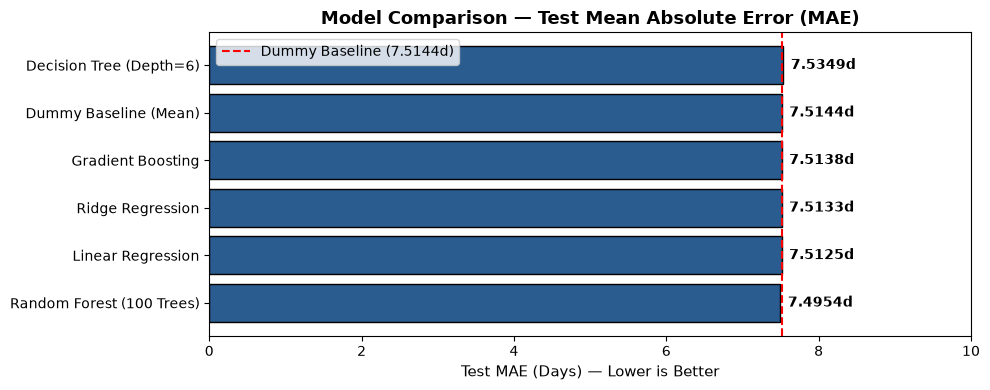

In [22]:
# Aggregate all benchmarked models into a formatted summary table
comparison_df = pd.DataFrame(results_list)[
    ['Model', 'Test MAE (days)', 'Test RMSE (days)', 'Test R²', 'Train MAE (days)', 'Train R²', 'Train Time (s)']
].sort_values(by='Test MAE (days)').reset_index(drop=True)

print("--- MODEL COMPARISON BENCHMARK ---")
display(comparison_df)

# Plot Test MAE comparison
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 4))
bars = plt.barh(comparison_df['Model'], comparison_df['Test MAE (days)'], color='#2b5c8f', edgecolor='black')
plt.axvline(dummy_results['Test MAE (days)'], color='red', linestyle='--', label=f"Dummy Baseline ({dummy_results['Test MAE (days)']}d)")
plt.xlabel("Test MAE (Days) — Lower is Better", fontsize=11)
plt.title("Model Comparison — Test Mean Absolute Error (MAE)", fontsize=13, fontweight='bold')
plt.xlim(0, 10)

for bar in bars:
    plt.text(bar.get_width() + 0.1, bar.get_y() + bar.get_height()/2, 
             f"{bar.get_width():.4f}d", va='center', fontweight='bold')

plt.legend()
plt.tight_layout()
plt.show()


In [23]:
from xgboost import XGBRegressor

# XGBoost Regressor
xgb = XGBRegressor(n_estimators=100, max_depth=4, learning_rate=0.05, random_state=42, n_jobs=-1)
xgb_results = evaluate_model("XGBoost Regressor", xgb, X_train_processed, y_train, X_test_processed, y_test)
results_list.append(xgb_results)

print(f"XGBoost Test MAE: {xgb_results['Test MAE (days)']} days | Train Time: {xgb_results['Train Time (s)']}s")


XGBoost Test MAE: 7.5133 days | Train Time: 0.7639s


In [24]:
# Full comparison ranking table
final_comparison_df = pd.DataFrame(results_list)[
    ['Model', 'Test MAE (days)', 'Test RMSE (days)', 'Test R²', 'Train MAE (days)', 'Train R²', 'Train Time (s)']
].sort_values(by='Test MAE (days)').reset_index(drop=True)

print("--- COMPLETE MODEL COMPARISON LEADERBOARD ---")
display(final_comparison_df)


--- COMPLETE MODEL COMPARISON LEADERBOARD ---


,Model,Test MAE (days),Test RMSE (days),Test R²,Train MAE (days),Train R²,Train Time (s)
0,Random Forest (100 Trees),7.4954,8.6514,0.0035,7.3432,0.0435,2.0901
1,Linear Regression,7.5125,8.6680,-0.0003,7.5081,0.0007,0.0430
2,XGBoost Regressor,7.5133,8.6700,-0.0008,7.4625,0.0119,0.7639
3,Ridge Regression,7.5133,8.6692,-0.0006,7.5076,0.0008,0.0176
4,Gradient Boosting,7.5138,8.6719,-0.0012,7.4592,0.0126,11.7555
5,Dummy Baseline (Mean),7.5144,8.6667,-0.0000,7.5126,0.0000,0.0011
6,Decision Tree (Depth=6),7.5349,8.7043,-0.0087,7.4679,0.0085,0.2347
